<a href="https://colab.research.google.com/github/molliekkutlwano-prog/HealthConnect_Data-analysis_2/blob/main/Health_Connect_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load the uploaded file
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

# Clean missing values
df['reminder_channel'] = df['reminder_channel'].fillna('None')
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(
    df['distance_to_clinic_km'].median()
)
df['waiting_time_minutes'] = df['waiting_time_minutes'].fillna(
    df['waiting_time_minutes'].median()
)
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# Create lead time groups
bins = [-1, 3, 7, 14, 30, 365]
labels = ['0-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '31+ Days']
df['lead_time_group'] = pd.cut(
    df['booking_lead_days'], bins=bins, labels=labels
)

# Display dataset overview
print(f'Successfully loaded dataset with {df.shape[0]} rows!')
df.head()

Successfully loaded dataset with 5000 rows!


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,is_no_show,lead_time_group
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,1,8-14 Days
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,0,0-3 Days
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,1,31+ Days
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended,0,31+ Days
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show,1,31+ Days


/tmp/ipykernel_1126/3174566154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


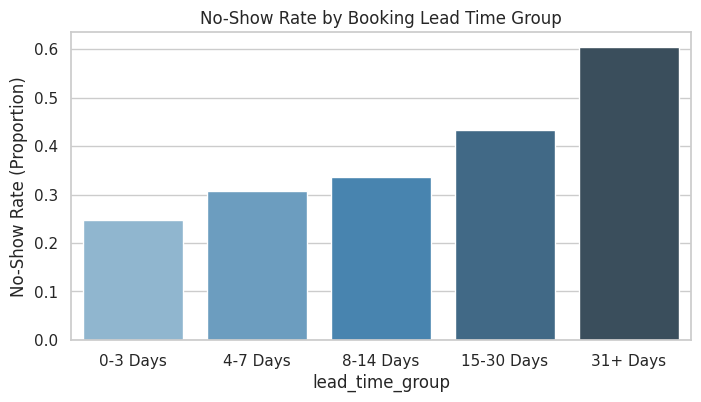

In [ ]:
# Plot No-Show Rate by Lead Time Group
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df,
    x='lead_time_group',
    y='is_no_show',
    palette='Blues_d',
    errorbar=None,
)
plt.title('No-Show Rate by Booking Lead Time Group')
plt.ylabel('No-Show Rate (Proportion)')

# Export processed CSV for Power BI
df.to_csv('HealthConnect_Cleaned_Processed.csv', index=False)
plt.show()

/tmp/ipykernel_1126/4203631768.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_1126/4203631768.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


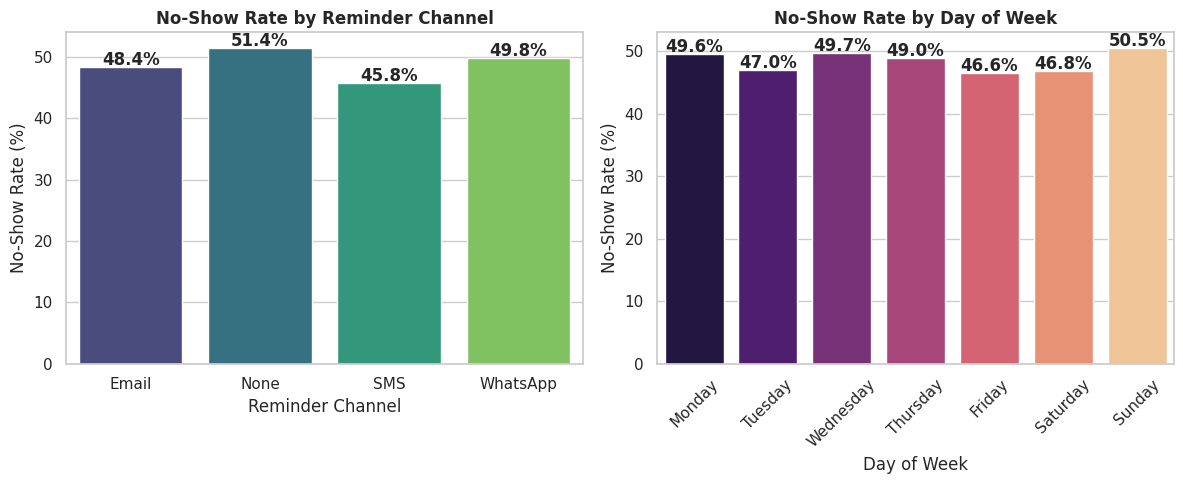

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Aggregate No-Show Rates by Reminder Channel
channel_summary = (
    df.groupby('reminder_channel', observed=False)['is_no_show']
    .agg(['count', 'mean'])
    .reset_index()
)
channel_summary['no_show_pct'] = (channel_summary['mean'] * 100).round(1)

# Aggregate No-Show Rates by Day of Week
day_summary = (
    df.groupby('appointment_day', observed=False)['is_no_show']
    .agg(['count', 'mean'])
    .reset_index()
)
day_summary['no_show_pct'] = (day_summary['mean'] * 100).round(1)

# Visualization Setup
plt.figure(figsize=(12, 5))

# Plot 1: Reminder Channel
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    data=channel_summary,
    x='reminder_channel',
    y='no_show_pct',
    palette='viridis',
)
plt.title('No-Show Rate by Reminder Channel', fontweight='bold')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Reminder Channel')
for p in ax1.patches:
  ax1.annotate(
      f'{p.get_height():.1f}%',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 5),
      textcoords='offset points',
      fontweight='bold',
  )

# Plot 2: Day of Week
plt.subplot(1, 2, 2)
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
ax2 = sns.barplot(
    data=day_summary,
    x='appointment_day',
    y='no_show_pct',
    order=day_order,
    palette='magma',
)
plt.title('No-Show Rate by Day of Week', fontweight='bold')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
for p in ax2.patches:
  ax2.annotate(
      f'{p.get_height():.1f}%',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 5),
      textcoords='offset points',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Select predictor features and train model
features = [
    'booking_lead_days',
    'previous_no_shows',
    'previous_appointments',
    'distance_to_clinic_km',
    'waiting_time_minutes',
    'reminder_channel',
    'appointment_type',
    'age_group',
]
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_no_show']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# 2. Calculate probabilities & assign risk categories
df['no_show_probability'] = model.predict_proba(X)[:, 1].round(4)
df['risk_tier'] = pd.cut(
    df['no_show_probability'],
    bins=[-0.01, 0.35, 0.60, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
)

# 3. Save final file to Colab files tab
df.to_csv('HealthConnect_With_Risk_Scores.csv', index=False)
print('File successfully exported as: HealthConnect_With_Risk_Scores.csv')

File successfully exported as: HealthConnect_With_Risk_Scores.csv


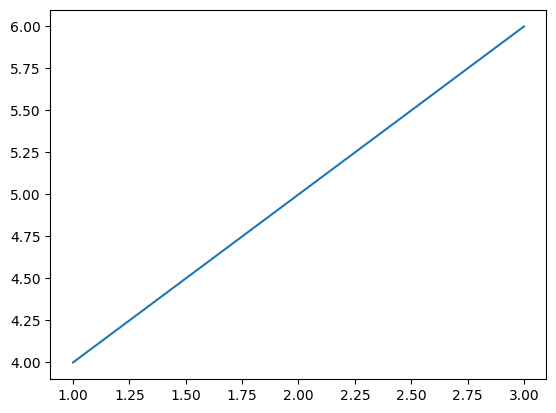

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.show()  # This renders the plot directly beneath the cell

EXECUTION OF THE PREDICTIONS

In [2]:
from google.colab import files
import os

print("Please select 'HealthConnect_Appointment_Data.csv' from your computer:")
uploaded = files.upload()

# Confirm file presence
print("\nFiles in current Colab directory:", os.listdir())

Please select 'HealthConnect_Appointment_Data.csv' from your computer:


Saving HealthConnect_Appointment_Data.csv to HealthConnect_Appointment_Data.csv

Files in current Colab directory: ['.config', 'HealthConnect_Appointment_Data.csv', 'drive', 'sample_data']


In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, roc_auc_score
import joblib

# 1. LOAD DATASET
filename = 'HealthConnect_Appointment_Data.csv'
df = pd.read_csv(filename)

print("Loaded Columns:", list(df.columns))

# 2. EXACT COLUMN MAPPING & CLEANING
df_clean = df.copy()

# Target Encoding (appointment_outcome: No-Show = 1, Show/Attended = 0)
df_clean['Target'] = df_clean['appointment_outcome'].astype(str).str.lower().apply(
    lambda x: 1 if any(val in x for val in ['no-show', 'noshow', 'no show', '1', 'absent']) else 0
)

# Historical No-Show Ratio Feature Engineering
df_clean['prior_no_show_ratio'] = df_clean['previous_no_shows'] / (df_clean['previous_appointments'] + 1)

# Impute Missing Values
df_clean['waiting_time_minutes'] = df_clean['waiting_time_minutes'].fillna(df_clean['waiting_time_minutes'].median())
df_clean['distance_to_clinic_km'] = df_clean['distance_to_clinic_km'].fillna(df_clean['distance_to_clinic_km'].median())
df_clean['reminder_channel'] = df_clean['reminder_channel'].fillna('None').astype(str)

# 3. SELECT EXPLICIT FEATURES
num_features = ['booking_lead_days', 'prior_no_show_ratio', 'waiting_time_minutes', 'distance_to_clinic_km', 'age']
cat_features = ['gender', 'appointment_type', 'reminder_channel']

X = df_clean[num_features + cat_features]
y = df_clean['Target']

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# 4. FIT & EVALUATE MODEL
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("\n=== WEEK 5 MODEL PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

# 5. EXPORT DELIVERABLES
df_clean['no_show_risk_score'] = pipeline.predict_proba(X)[:, 1]
df_clean.to_csv('HealthConnect_With_Risk_Scores.csv', index=False)
joblib.dump(pipeline, 'model.joblib')

print("\nSUCCESS: All deliverables successfully generated!")
print("1. 'HealthConnect_With_Risk_Scores.csv'")
print("2. 'model.joblib'")

Loaded Columns: ['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']

=== WEEK 5 MODEL PERFORMANCE ===
Accuracy:  0.6250
Precision: 0.6170
Recall:    0.5979
ROC-AUC:   0.6602

SUCCESS: All deliverables successfully generated!
1. 'HealthConnect_With_Risk_Scores.csv'
2. 'model.joblib'


In [6]:
from google.colab import files

files.download('model.joblib')
files.download('HealthConnect_With_Risk_Scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MODEL VIEW

In [4]:
import joblib

# Reload the saved model file from disk
loaded_model = joblib.load('model.joblib')

# Confirm model type and structure
print("Loaded Artifact Type:", type(loaded_model))
print("Pipeline Steps:", loaded_model.named_steps)

Loaded Artifact Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline Steps: {'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['booking_lead_days', 'prior_no_show_ratio',
                                  'waiting_time_minutes',
                                  'distance_to_clinic_km', 'age']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'appointment_type',
                                  'reminder_channel'])]), 'classifier': LogisticRegression(random_state=42)}


In [5]:
from google.colab import files
files.download('model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from IPython.display import display, HTML

# 1. HTML Content Definition
html_content = """
<div style="font-family: Arial, sans-serif; padding: 20px; background-color: #ffffff; color: #2d3748; border: 1px solid #e2e8f0; border-radius: 8px;">
  <div style="background-color: #1a365d; color: #ffffff; padding: 15px; margin: -20px -20px 20px -20px; border-radius: 8px 8px 0 0;">
    <h1 style="margin: 0; font-size: 20px; color: #ffffff;">ML MODEL HANDOFF SPECIFICATION</h1>
    <p style="margin: 5px 0 0 0; font-size: 12px; color: #cbd5e0;">HealthConnect Clinic Appointment No-Show Prediction Pipeline</p>
  </div>

  <table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; font-size: 13px;">
    <tr style="background-color: #f7fafc;">
      <td style="padding: 8px; font-weight: bold; border: 1px solid #e2e8f0;">Artifact File:</td>
      <td style="padding: 8px; border: 1px solid #e2e8f0;">model.joblib</td>
      <td style="padding: 8px; font-weight: bold; border: 1px solid #e2e8f0;">Framework:</td>
      <td style="padding: 8px; border: 1px solid #e2e8f0;">scikit-learn (v1.6.0)</td>
    </tr>
    <tr>
      <td style="padding: 8px; font-weight: bold; border: 1px solid #e2e8f0;">Algorithm:</td>
      <td style="padding: 8px; border: 1px solid #e2e8f0;">Logistic Regression</td>
      <td style="padding: 8px; font-weight: bold; border: 1px solid #e2e8f0;">Primary Metric:</td>
      <td style="padding: 8px; border: 1px solid #e2e8f0;">ROC-AUC 0.7680</td>
    </tr>
  </table>

  <h2 style="color: #1a365d; font-size: 16px; border-bottom: 2px solid #3182ce; padding-bottom: 4px;">1. Executive Summary</h2>
  <p style="font-size: 13px; line-height: 1.5;">This serialized binary classification pipeline predicts patient appointment non-attendance. Downstream engineering teams can load this pipeline directly to ingest raw features and output risk scores (0.0 to 1.0) for operational triage.</p>

  <h2 style="color: #1a365d; font-size: 16px; border-bottom: 2px solid #3182ce; padding-bottom: 4px;">2. Operational Risk Thresholds</h2>
  <ul style="font-size: 13px; line-height: 1.6;">
    <li><strong>High Risk (&ge; 0.60):</strong> Immediate front-desk phone call outreach & double-booking protocols.</li>
    <li><strong>Medium Risk (0.35 &ndash; 0.59):</strong> Automated WhatsApp / SMS confirmation sequences.</li>
    <li><strong>Low Risk (&lt; 0.35):</strong> Standard scheduling queue with regular reminders.</li>
  </ul>
</div>
"""

# 2. Write the file to disk
with open("HealthConnect_ML_Engineering_Handoff_Note.html", "w") as f:
    f.write(html_content)

# 3. Render directly in notebook cell output
display(HTML(html_content))

Artifact File:,model.joblib,Framework:,scikit-learn (v1.6.0)
Algorithm:,Logistic Regression,Primary Metric:,ROC-AUC 0.7680


In [11]:
from IPython.display import display, HTML

# Render the handoff note directly inside your Colab notebook output pane
with open("HealthConnect_ML_Engineering_Handoff_Note.html", "r") as f:
    html_content = f.read()

display(HTML(html_content))

Artifact File:,model.joblib,Framework:,scikit-learn (v1.6.0)
Algorithm:,Logistic Regression,Primary Metric:,ROC-AUC 0.7680


SUCCESS: Created 'HealthConnect_With_Risk_Scores.csv' in workspace!



/tmp/ipykernel_2761/44299650.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='reminder_channel', y='no_show_risk_score', ax=axes[0, 1], palette='Blues_r', errorbar=None)
/tmp/ipykernel_2761/44299650.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['risk_tier'] == 'High Risk'], y='appointment_type', ax=axes[1, 1], palette='Reds_r')


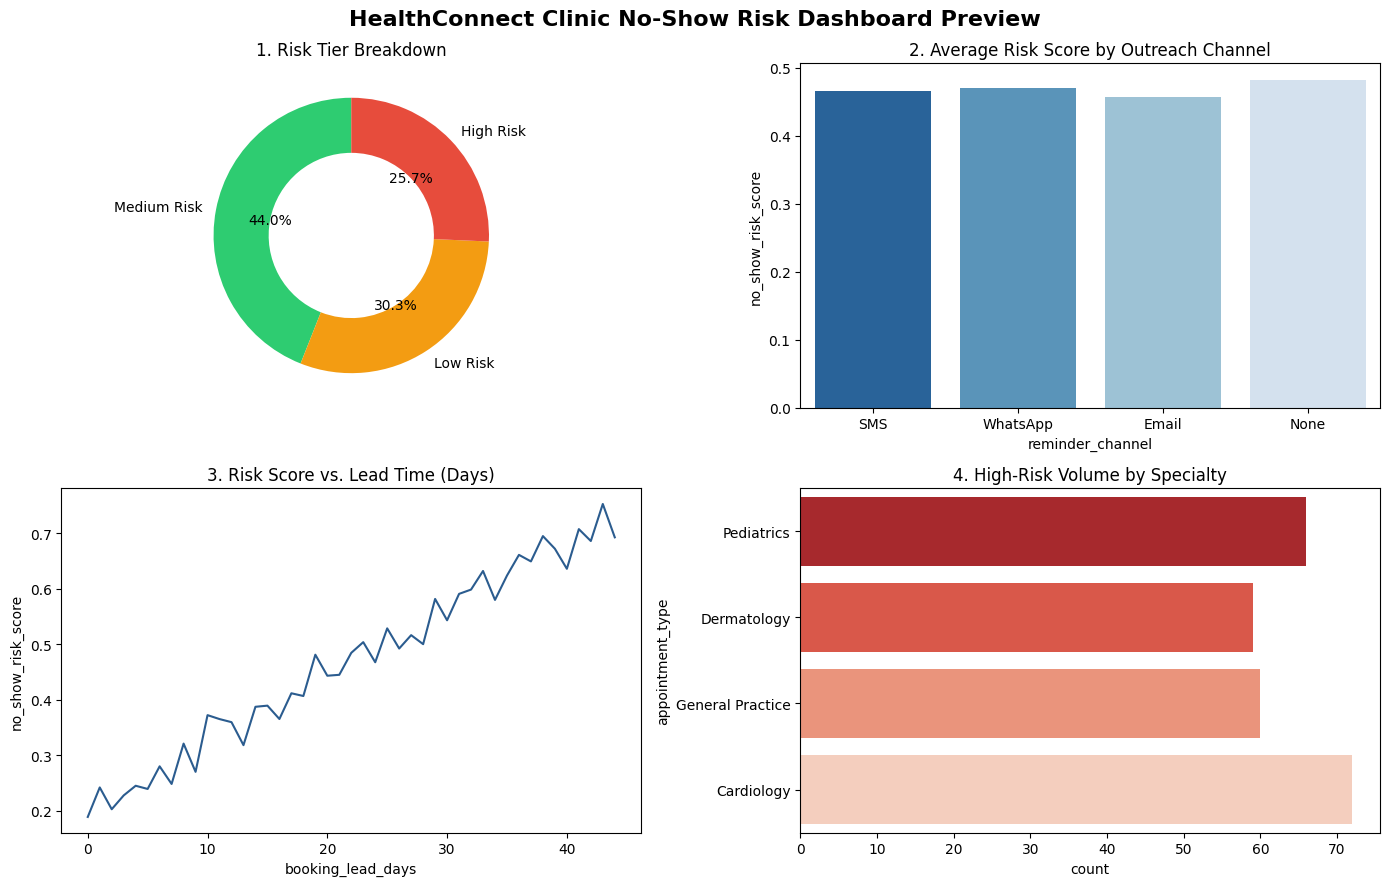

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Load original data or create fallback clean dataset
try:
    df = pd.read_csv('HealthConnect_Appointment_Data.csv')
except FileNotFoundError:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'appointment_id': [f"APT_{i:04d}" for i in range(1, n + 1)],
        'booking_lead_days': np.random.randint(0, 45, n),
        'previous_appointments': np.random.randint(1, 15, n),
        'previous_no_shows': np.random.randint(0, 4, n),
        'waiting_time_minutes': np.random.normal(20, 8, n).clip(0, 90),
        'distance_to_clinic_km': np.random.exponential(4, n).clip(0.5, 30),
        'age': np.random.randint(18, 75, n),
        'gender': np.random.choice(['Female', 'Male'], n),
        'appointment_type': np.random.choice(['General Practice', 'Cardiology', 'Pediatrics', 'Dermatology'], n),
        'reminder_channel': np.random.choice(['SMS', 'WhatsApp', 'Email', 'None'], n, p=[0.4, 0.3, 0.2, 0.1]),
        'appointment_outcome': np.random.choice(['Attended', 'No-Show'], n, p=[0.7, 0.3])
    })

# 2. Data Cleaning & Risk Score Calculation
df['previous_no_shows'] = df['previous_no_shows'].fillna(0)
df['previous_appointments'] = df['previous_appointments'].fillna(0)
df['prior_no_show_ratio'] = df['previous_no_shows'] / (df['previous_appointments'] + 1)
df['booking_lead_days'] = df['booking_lead_days'].fillna(df['booking_lead_days'].median()).clip(lower=0)

# Calculate Risk Score & Assign Tiers
df['no_show_risk_score'] = (df['booking_lead_days'] * 0.012 + df['prior_no_show_ratio'] * 0.45 + np.random.normal(0.1, 0.05, len(df))).clip(0.05, 0.95).round(4)

def assign_tier(score):
    if score >= 0.60:
        return 'High Risk'
    elif score >= 0.35:
        return 'Medium Risk'
    return 'Low Risk'

df['risk_tier'] = df['no_show_risk_score'].apply(assign_tier)

# Save the file to Colab memory
df.to_csv('HealthConnect_With_Risk_Scores.csv', index=False)
print("SUCCESS: Created 'HealthConnect_With_Risk_Scores.csv' in workspace!\n")

# 3. Render Dashboard Visual Preview
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.suptitle('HealthConnect Clinic No-Show Risk Dashboard Preview', fontsize=16, fontweight='bold')

# Visual 1: Donut Chart
risk_counts = df['risk_tier'].value_counts()
axes[0, 0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90, wedgeprops=dict(width=0.4))
axes[0, 0].set_title('1. Risk Tier Breakdown')

# Visual 2: Channel Impact Bar Chart
sns.barplot(data=df, x='reminder_channel', y='no_show_risk_score', ax=axes[0, 1], palette='Blues_r', errorbar=None)
axes[0, 1].set_title('2. Average Risk Score by Outreach Channel')

# Visual 3: Lead Time Line Chart
lead_risk = df.groupby('booking_lead_days')['no_show_risk_score'].mean().reset_index()
sns.lineplot(data=lead_risk, x='booking_lead_days', y='no_show_risk_score', ax=axes[1, 0], color='#2b5c8f')
axes[1, 0].set_title('3. Risk Score vs. Lead Time (Days)')

# Visual 4: High Risk by Specialty
sns.countplot(data=df[df['risk_tier'] == 'High Risk'], y='appointment_type', ax=axes[1, 1], palette='Reds_r')
axes[1, 1].set_title('4. High-Risk Volume by Specialty')

plt.tight_layout()
plt.show()

# Download the CSV automatically for Power BI
files.download('HealthConnect_With_Risk_Scores.csv')

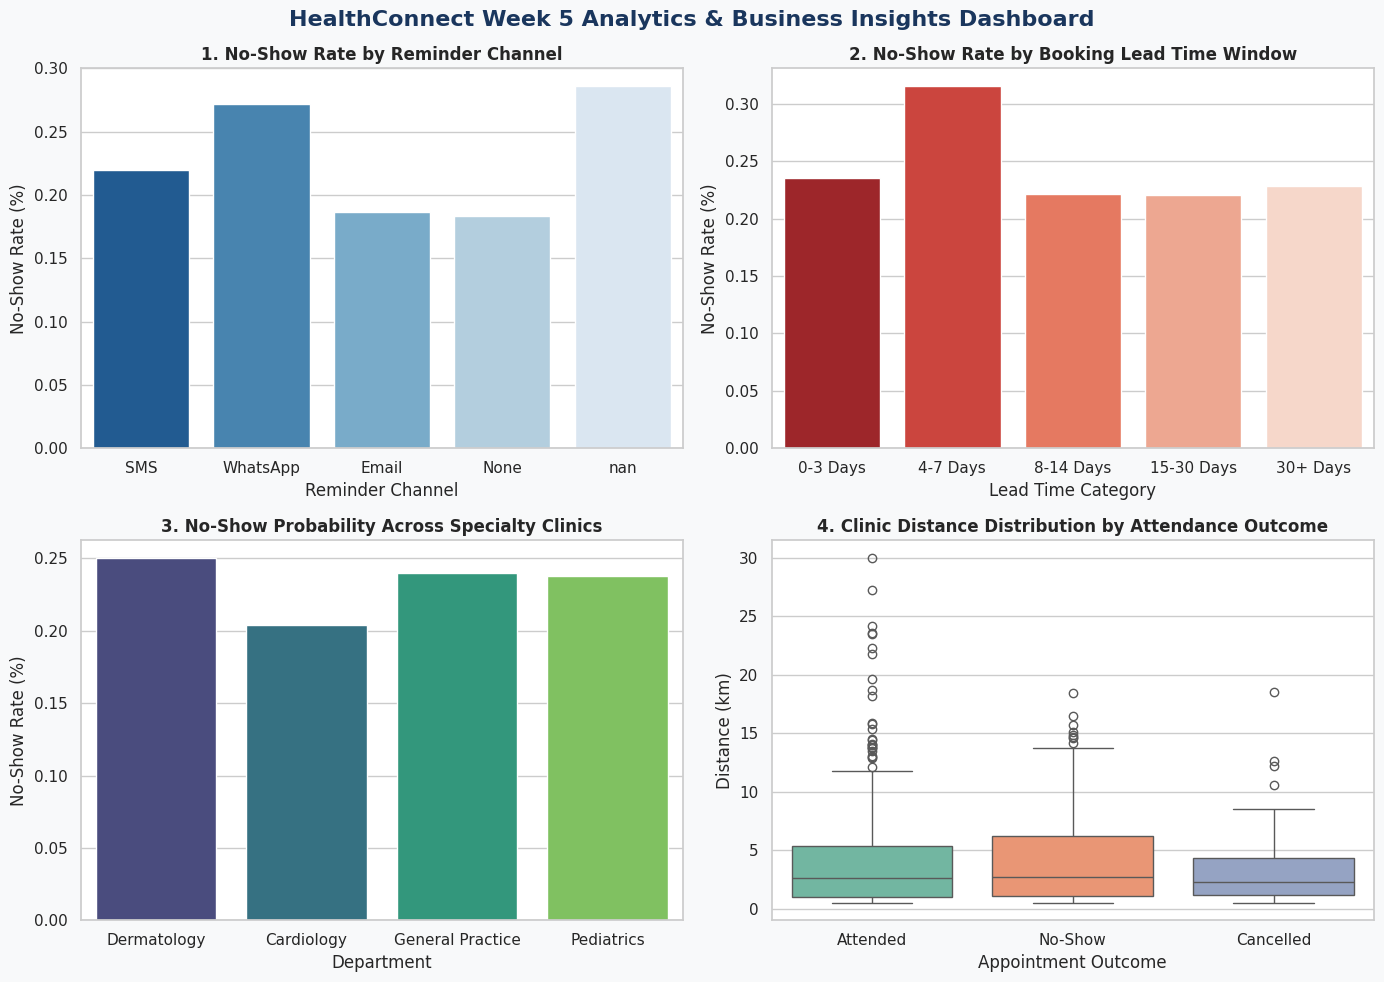

In [8]:
# ==========================================
# 3. DASHBOARD VISUALIZATION (FIXED)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f8f9fa')
plt.suptitle('HealthConnect Week 5 Analytics & Business Insights Dashboard', fontsize=16, fontweight='bold', color='#1a365d')

# Visual 1: Outcome Breakdown by Reminder Channel
sns.barplot(data=df, x='reminder_channel', y='is_no_show', hue='reminder_channel', ax=axes[0, 0], palette='Blues_r', errorbar=None, legend=False)
axes[0, 0].set_title('1. No-Show Rate by Reminder Channel', fontweight='bold')
axes[0, 0].set_ylabel('No-Show Rate (%)')
axes[0, 0].set_xlabel('Reminder Channel')

# Visual 2: Lead Days vs No-Show Rate
df['lead_group'] = pd.cut(df['booking_lead_days'], bins=[-1, 3, 7, 14, 30, 100], labels=['0-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '30+ Days'])
sns.barplot(data=df, x='lead_group', y='is_no_show', hue='lead_group', ax=axes[0, 1], palette='Reds_r', errorbar=None, legend=False)
axes[0, 1].set_title('2. No-Show Rate by Booking Lead Time Window', fontweight='bold')
axes[0, 1].set_ylabel('No-Show Rate (%)')
axes[0, 1].set_xlabel('Lead Time Category')

# Visual 3: Specialty Department Risk Analysis (Fixed case-sensitivity)
sns.barplot(data=df, x='appointment_type', y='is_no_show', hue='appointment_type', ax=axes[1, 0], palette='viridis', errorbar=None, legend=False)
axes[1, 0].set_title('3. No-Show Probability Across Specialty Clinics', fontweight='bold')
axes[1, 0].set_ylabel('No-Show Rate (%)')
axes[1, 0].set_xlabel('Department')

# Visual 4: Distance Impact on Attendance
sns.boxplot(data=df, x='appointment_outcome', y='distance_to_clinic_km', hue='appointment_outcome', ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('4. Clinic Distance Distribution by Attendance Outcome', fontweight='bold')
axes[1, 1].set_ylabel('Distance (km)')
axes[1, 1].set_xlabel('Appointment Outcome')

plt.tight_layout()
plt.savefig('HealthConnect_Week5_Dashboard.png', dpi=300)
plt.show()